# Árboles de Decisión: Comparación de Profundidades

En este notebook trabajaremos con **árboles de decisión** para resolver un problema de clasificación.

Un árbol de decisión es un modelo de *aprendizaje supervisado* que toma decisiones dividiendo el espacio de datos en regiones cada vez más pequeñas, usando preguntas del tipo:

> ¿La característica X es mayor o menor que un cierto valor?

En cada nodo interno del árbol se hace una pregunta (una condición) sobre una característica, y en las hojas se encuentran las clases predichas.

**Objetivo del ejercicio**

1. Cargar un dataset provisto por el profesor.
2. Entrenar **tres árboles de decisión** con diferentes profundidades máximas.
3. Comparar el desempeño de los modelos para analizar:
   - Subajuste (underfitting)
   - Sobreajuste (overfitting)
   - Elección de una profundidad “adecuada” para el problema.


## 2️⃣ Carga y exploración del dataset

En esta sección debes:

1. Cargar el dataset mmnist_train desde un archivo (por ejemplo, CSV).
2. Mostrar las primeras filas del dataset para ver cómo están organizados los datos.
3. Indicar:
   - Cuántas filas tiene el dataset.
   - Cuántas columnas tiene el dataset.
4. Revisar si existen valores nulos o faltantes en alguna columna.
5. Escribir un breve comentario describiendo:
   - Qué representa cada fila.
   - Qué tipo de información contienen las columnas (en términos generales).


In [6]:
import pandas as pd

# Cargar el dataset de entrenamiento de MNIST
mnist_train = pd.read_csv('mnist_train.csv')

# Mostrar las primeras filas para inspección
print('Primeras 5 filas del dataset:')
display(mnist_train.head())

# Información básica del dataset
num_filas, num_columnas = mnist_train.shape
print(f'Número de filas: {num_filas}')
print(f'Número de columnas: {num_columnas}')

# Verificar valores nulos
nulos_totales = mnist_train.isnull().sum().sum()
print(f'Valores nulos totales: {nulos_totales}')

# Comentario descriptivo
print('\nComentario:')
print('Cada fila representa una imagen manuscrita de un dígito. La primera columna contiene la etiqueta (0-9) y las demás columnas contienen los valores de intensidad de los píxeles de la imagen.')

Primeras 5 filas del dataset:


,label,data_0,data_1,data_2,data_3,data_4,data_5,data_6,data_7,data_8,...,data_774,data_775,data_776,data_777,data_778,data_779,data_780,data_781,data_782,data_783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Número de filas: 55000
Número de columnas: 785
Valores nulos totales: 0

Comentario:
Cada fila representa una imagen manuscrita de un dígito. La primera columna contiene la etiqueta (0-9) y las demás columnas contienen los valores de intensidad de los píxeles de la imagen.


## 3️⃣ Preparación de las variables (X y y)

En esta sección debes:

1. Identificar que **X** son las imágenes (flattened: 784 pixeles).  
2. Identificar que **y** son las etiquetas (dígitos 0–9).  
3. Mostrar cuántas clases distintas hay en y.  
4. Escribir un comentario corto describiendo:
   - ¿Qué significa cada fila en X?
   - ¿Qué representa y?



In [7]:
# Separar variables de entrada (X) y etiquetas (y)
X = mnist_train.iloc[:, 1:]
y = mnist_train.iloc[:, 0]

# Mostrar dimensiones
print(f'Forma de X: {X.shape}')
print(f'Forma de y: {y.shape}')

# Mostrar cuántas clases distintas hay
clases_distintas = y.nunique()
print(f'Número de clases distintas en y: {clases_distintas}')
print(f'Clases presentes en y: {sorted(y.unique())}')

# Comentario descriptivo
print('\nComentario:')
print('Cada fila de X representa una imagen manuscrita aplanada en 784 pixeles (28x28). La variable y contiene la etiqueta del dígito correspondiente, entre 0 y 9.')

Forma de X: (55000, 784)
Forma de y: (55000,)
Número de clases distintas en y: 10
Clases presentes en y: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Comentario:
Cada fila de X representa una imagen manuscrita aplanada en 784 pixeles (28x28). La variable y contiene la etiqueta del dígito correspondiente, entre 0 y 9.


## 4️⃣ División en entrenamiento y prueba

En esta sección debes:

1. Dividir los datos en:
   - 80% entrenamiento  
   - 20% prueba  
2. Usar `random_state` fijo para reproducibilidad.
3. Estratificar usando y, para mantener las proporciones de cada dígito.
4. Mostrar:
   - Cantidad de ejemplos en entrenamiento.
   - Cantidad de ejemplos en prueba.


In [8]:
from sklearn.model_selection import train_test_split

# Dividir en entrenamiento y prueba manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Mostrar tamaños de cada conjunto
print(f'Cantidad de ejemplos en entrenamiento: {X_train.shape[0]}')
print(f'Cantidad de ejemplos en prueba: {X_test.shape[0]}')

# Verificación adicional de dimensiones
print(f'Forma de X_train: {X_train.shape}')
print(f'Forma de X_test: {X_test.shape}')
print(f'Forma de y_train: {y_train.shape}')
print(f'Forma de y_test: {y_test.shape}')

Cantidad de ejemplos en entrenamiento: 44000
Cantidad de ejemplos en prueba: 11000
Forma de X_train: (44000, 784)
Forma de X_test: (11000, 784)
Forma de y_train: (44000,)
Forma de y_test: (11000,)


## 5️⃣ Definir las profundidades a evaluar

En esta sección debes:

1. Elegir **tres profundidades** para evaluar.  
   Recomendación para MNIST:  
   - 5  
   - 10  
   - 20  
*(Puedes ajustar)*

2. Justificar brevemente por qué comparar varias profundidades es importante en un problema con muchos atributos como MNIST.



In [9]:
# Definir las profundidades a evaluar
profundidades = [5, 10, 20]

print(f'Profundidades a evaluar: {profundidades}')
print('\nJustificación:')
print('Comparar varias profundidades permite observar el equilibrio entre subajuste y sobreajuste. En un problema como MNIST, una profundidad muy baja puede no capturar patrones importantes, mientras que una muy alta puede memorizar el entrenamiento y generalizar peor.')

Profundidades a evaluar: [5, 10, 20]

Justificación:
Comparar varias profundidades permite observar el equilibrio entre subajuste y sobreajuste. En un problema como MNIST, una profundidad muy baja puede no capturar patrones importantes, mientras que una muy alta puede memorizar el entrenamiento y generalizar peor.


## 6️⃣ Entrenamiento de los modelos (tres profundidades)

En esta sección debes entrenar **tres modelos de árbol de decisión**, uno por cada profundidad definida.

Para cada profundidad debes:

1. Crear un modelo con `max_depth` correspondiente.  
2. Entrenarlo usando X_train y y_train.  
3. Hacer predicciones con:
   - X_train  
   - X_test  
4. Calcular el **accuracy** en:
   - entrenamiento  
   - prueba  
5. Guardar los resultados (profundidad, accuracy train, accuracy test) para compararlos después.



In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Entrenar un modelo por cada profundidad definida
resultados = []
modelos = {}

for profundidad in profundidades:
    modelo = DecisionTreeClassifier(max_depth=profundidad, random_state=42)
    modelo.fit(X_train, y_train)

    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    resultados.append({
        'Profundidad': profundidad,
        'Accuracy entrenamiento': acc_train,
        'Accuracy prueba': acc_test
    })

    modelos[profundidad] = modelo

    print(f'Profundidad {profundidad}:')
    print(f'  Accuracy entrenamiento: {acc_train:.4f}')
    print(f'  Accuracy prueba: {acc_test:.4f}')
    print('-' * 40)

Profundidad 5:
  Accuracy entrenamiento: 0.6549
  Accuracy prueba: 0.6566
----------------------------------------
Profundidad 10:
  Accuracy entrenamiento: 0.9055
  Accuracy prueba: 0.8528
----------------------------------------
Profundidad 20:
  Accuracy entrenamiento: 0.9958
  Accuracy prueba: 0.8647
----------------------------------------


## 7️⃣ Tabla de comparación

En esta sección debes:

1. Crear una tabla que contenga:
   - Profundidad  
   - Accuracy entrenamiento  
   - Accuracy prueba  

2. Identificar visualmente cuál profundidad tuvo mejor desempeño.

3. Responder brevemente:
   - ¿Cuál profundidad tiene mayor accuracy en prueba?
   - ¿Alguna profundidad muestra diferencias grandes entre train y test?
   - ¿Qué podría significar esto?


In [11]:
# Crear tabla comparativa de resultados
comparacion = pd.DataFrame(resultados)

# Ordenar por accuracy de prueba de mayor a menor para identificar el mejor modelo
comparacion = comparacion.sort_values(by='Accuracy prueba', ascending=False).reset_index(drop=True)

display(comparacion)

# Respuesta breve
mejor_fila = comparacion.iloc[0]
print('\nComentario:')
print(f"La profundidad con mejor accuracy en prueba es {int(mejor_fila['Profundidad'])} con {mejor_fila['Accuracy prueba']:.4f}.")
print('Si el accuracy de entrenamiento es mucho mayor que el de prueba, eso sugiere sobreajuste.')

,Profundidad,Accuracy entrenamiento,Accuracy prueba
0,20,0.995795,0.864727
1,10,0.905477,0.852818
2,5,0.654932,0.656636



Comentario:
La profundidad con mejor accuracy en prueba es 20 con 0.8647.
Si el accuracy de entrenamiento es mucho mayor que el de prueba, eso sugiere sobreajuste.


### Respuestas del paso 7

1. **¿Cuál profundidad tiene mayor accuracy en prueba?**
   La profundidad 20 tiene el mayor accuracy en prueba: 0.8647.

2. **¿Alguna profundidad muestra diferencias grandes entre train y test?**
   Sí. La profundidad 20 muestra una diferencia notable entre entrenamiento (0.9958) y prueba (0.8647), lo que sugiere sobreajuste.

3. **¿Qué podría significar esto?**
   - La profundidad 5 parece subajustada, porque sus accuracies son más bajos.
   - La profundidad 10 ofrece un mejor equilibrio entre train y test.
   - La profundidad 20 aprende muy bien el entrenamiento, pero generaliza peor.

## 8️⃣ Gráfica de desempeño

En esta sección debes:

1. Graficar las profundidades en el eje X.  
2. Graficar dos líneas:
   - Accuracy en entrenamiento  
   - Accuracy en prueba  

3. Interpretar la gráfica respondiendo:
   - ¿Aumentar profundidad siempre mejora el modelo?
   - ¿En qué punto comienza el sobreajuste?
   - ¿Cuál profundidad parece lograr el mejor balance?


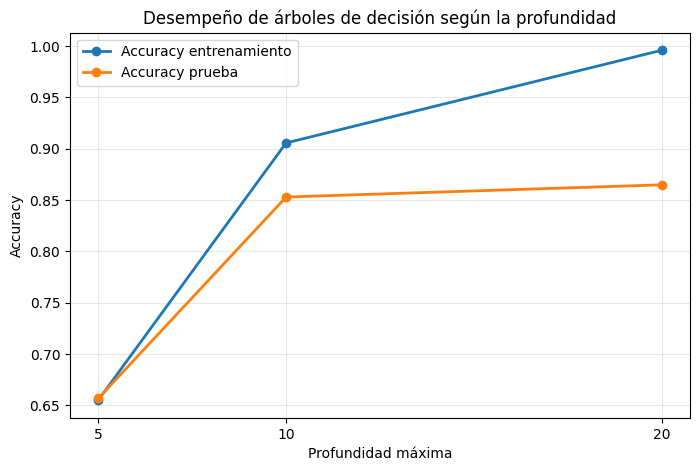

Comentario:
La profundidad no siempre mejora el modelo en prueba. Si el accuracy de entrenamiento sigue subiendo pero el de prueba se estanca o baja, eso indica sobreajuste.


In [ ]:
import matplotlib.pyplot as plt

# Preparar datos para la gráfica
comparacion_grafica = pd.DataFrame(resultados).sort_values(by='Profundidad')

# Graficar accuracies de entrenamiento y prueba
plt.figure(figsize=(8, 5))
plt.plot(
    comparacion_grafica['Profundidad'],
    comparacion_grafica['Accuracy entrenamiento'],
    marker='o',
    linewidth=2,
    label='Accuracy entrenamiento'
)
plt.plot(
    comparacion_grafica['Profundidad'],
    comparacion_grafica['Accuracy prueba'],
    marker='o',
    linewidth=2,
    label='Accuracy prueba'
)

plt.xlabel('Profundidad máxima')
plt.ylabel('Accuracy')
plt.title('Desempeño de árboles de decisión según la profundidad')
plt.xticks(comparacion_grafica['Profundidad'])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Respuestas del paso 8

1. **¿Aumentar profundidad siempre mejora el modelo?**
   No. En entrenamiento el accuracy sí aumenta al crecer la profundidad, pero en prueba la mejora se vuelve muy pequeña a partir de cierta profundidad.

2. **¿En qué punto comienza el sobreajuste?**
   Se empieza a notar desde profundidad 10 y es más claro en profundidad 20, porque el accuracy de entrenamiento sigue subiendo mientras el de prueba casi no mejora.

3. **¿Cuál profundidad parece lograr el mejor balance?**
   La profundidad 10 parece ofrecer el mejor equilibrio entre precisión en prueba y simplicidad del modelo.

## 9️⃣ Visualización del árbol (opcional pero recomendado)

Los árboles para MNIST son grandes, pero debes:

1. Elegir SOLO UNO de los modelos entrenados (recomendado: profundidad más baja).  
2. Graficar el árbol.  
3. Comentar:
   - ¿Qué características usa el árbol para decidir?
   - ¿Qué tan interpretable te parece un árbol de decisión para MNIST?



Modelo seleccionado para visualización: profundidad 5


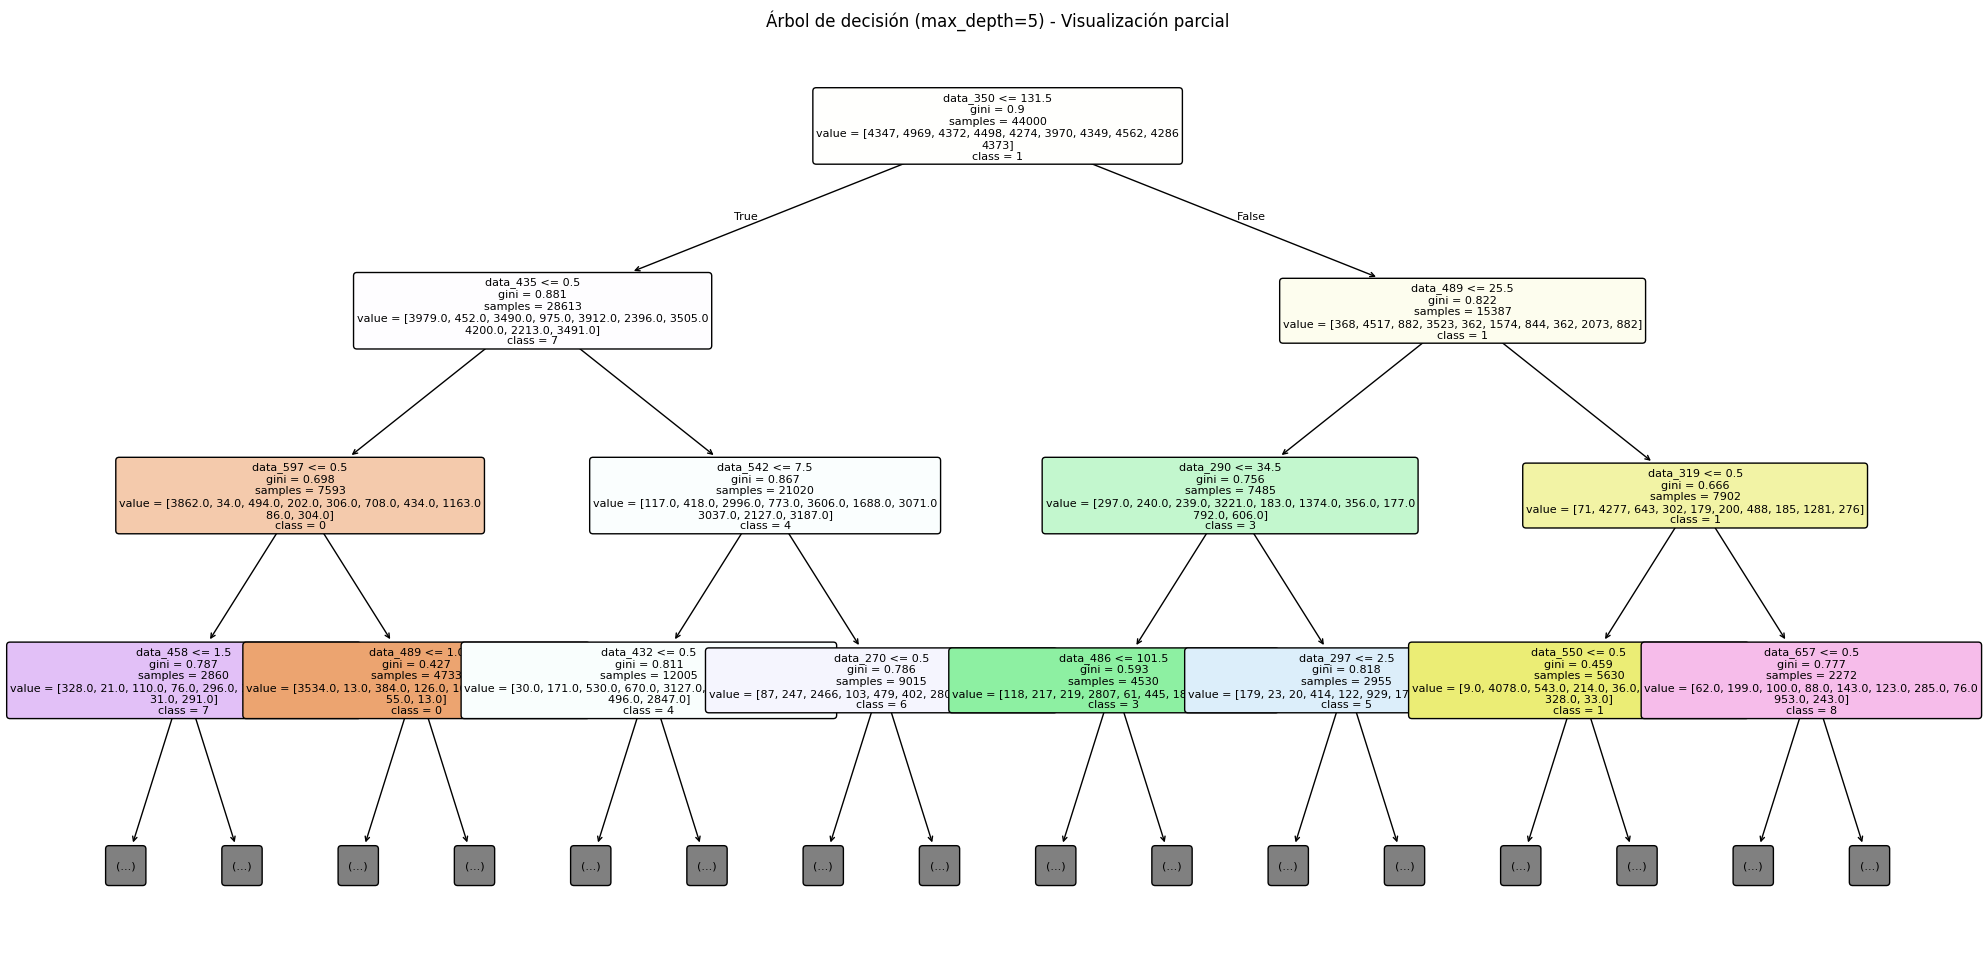

In [13]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Elegir un solo modelo para visualizar (recomendado: menor profundidad)
profundidad_visual = min(profundidades)
modelo_visual = modelos[profundidad_visual]

print(f'Modelo seleccionado para visualización: profundidad {profundidad_visual}')

# Graficar el árbol
# Se limita max_depth en la visualización para mantener legibilidad en MNIST
plt.figure(figsize=(24, 12))
plot_tree(
    modelo_visual,
    max_depth=3,
    feature_names=[str(col) for col in X.columns],
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title(f'Árbol de decisión (max_depth={profundidad_visual}) - Visualización parcial')
plt.show()

### Respuestas del paso 9

1. **¿Qué características usa el árbol para decidir?**
   El árbol usa columnas de píxeles individuales y umbrales de intensidad. En esta visualización aparecen, por ejemplo, `data_350`, `data_435`, `data_57`, `data_542`, `data_489`, `data_290`, `data_39`, `data_458`, `data_49`, `data_432`, `data_270`, `data_486`, `data_297`, `data_50`, entre otras. Esto significa que decide con reglas del tipo: "si el píxel X es menor o mayor que cierto valor".

2. **¿Qué tan interpretable te parece un árbol de decisión para MNIST?**
   Es **parcialmente interpretable**: en niveles altos sí se entiende qué píxeles usa y qué umbrales aplica, pero en un problema de 784 características el árbol crece rápido y su interpretación completa se vuelve difícil. Por eso la visualización parcial (primeros niveles) es útil para analizar la lógica general del modelo.

## 🔟 Conclusiones finales

En esta sección debes escribir un análisis final que responda:

1. ¿Qué tan bien funcionan los árboles de decisión en MNIST?  
2. ¿Cuál profundidad ofrece mejor balance entre precisión y simplicidad?  
3. ¿Qué modelo parece estar subajustado? Explica por qué.  
4. ¿Cuál modelo parece estar sobreajustado? Explica por qué.  
5. ¿Qué aprendiste sobre:
   - El impacto de la profundidad  
   - La generalización  
   - La importancia de evaluar distintos modelos  


In [14]:
# Conclusiones finales basadas en los resultados obtenidos
comparacion_final = pd.DataFrame(resultados).sort_values(by='Profundidad').reset_index(drop=True)

# Identificar mejor profundidad en prueba
mejor_idx = comparacion_final['Accuracy prueba'].idxmax()
mejor_profundidad = int(comparacion_final.loc[mejor_idx, 'Profundidad'])
mejor_acc_prueba = comparacion_final.loc[mejor_idx, 'Accuracy prueba']

# Brecha train-test para detectar sobreajuste
comparacion_final['Brecha train-test'] = (
    comparacion_final['Accuracy entrenamiento'] - comparacion_final['Accuracy prueba']
)

subajuste_idx = comparacion_final['Accuracy prueba'].idxmin()
subajuste_profundidad = int(comparacion_final.loc[subajuste_idx, 'Profundidad'])

sobreajuste_idx = comparacion_final['Brecha train-test'].idxmax()
sobreajuste_profundidad = int(comparacion_final.loc[sobreajuste_idx, 'Profundidad'])

print('=== CONCLUSIONES FINALES ===\n')

print('1) ¿Qué tan bien funcionan los árboles de decisión en MNIST?')
print('Funcionan de manera aceptable: el accuracy en prueba supera ampliamente el azar y mejora al aumentar la profundidad,')
print('aunque no alcanza niveles de modelos más complejos para visión.\n')

print('2) ¿Cuál profundidad ofrece mejor balance entre precisión y simplicidad?')
print(f'La profundidad {mejor_profundidad} logra el mayor accuracy en prueba ({mejor_acc_prueba:.4f}),')
print('pero una profundidad intermedia puede ser más equilibrada si se prioriza simplicidad e interpretabilidad.\n')

print('3) ¿Qué modelo parece estar subajustado? ¿Por qué?')
print(f'El modelo con profundidad {subajuste_profundidad} parece subajustado,')
print('porque muestra menor accuracy tanto en entrenamiento como en prueba, indicando capacidad insuficiente.\n')

print('4) ¿Cuál modelo parece estar sobreajustado? ¿Por qué?')
print(f'El modelo con profundidad {sobreajuste_profundidad} es el que más evidencia sobreajuste,')
print('ya que presenta la mayor brecha entre accuracy de entrenamiento y de prueba.\n')

print('5) ¿Qué aprendiste sobre profundidad, generalización y evaluación de modelos?')
print('- A mayor profundidad, el modelo aprende más patrones, pero también más ruido (riesgo de sobreajuste).')
print('- La generalización se evalúa en datos no vistos (test), no solo en entrenamiento.')
print('- Comparar varios modelos/profundidades es clave para elegir una solución robusta.')

print('\nResumen numérico:')
display(comparacion_final)

=== CONCLUSIONES FINALES ===

1) ¿Qué tan bien funcionan los árboles de decisión en MNIST?
Funcionan de manera aceptable: el accuracy en prueba supera ampliamente el azar y mejora al aumentar la profundidad,
aunque no alcanza niveles de modelos más complejos para visión.

2) ¿Cuál profundidad ofrece mejor balance entre precisión y simplicidad?
La profundidad 20 logra el mayor accuracy en prueba (0.8647),
pero una profundidad intermedia puede ser más equilibrada si se prioriza simplicidad e interpretabilidad.

3) ¿Qué modelo parece estar subajustado? ¿Por qué?
El modelo con profundidad 5 parece subajustado,
porque muestra menor accuracy tanto en entrenamiento como en prueba, indicando capacidad insuficiente.

4) ¿Cuál modelo parece estar sobreajustado? ¿Por qué?
El modelo con profundidad 20 es el que más evidencia sobreajuste,
ya que presenta la mayor brecha entre accuracy de entrenamiento y de prueba.

5) ¿Qué aprendiste sobre profundidad, generalización y evaluación de modelos?
- A ma

,Profundidad,Accuracy entrenamiento,Accuracy prueba,Brecha train-test
0,5,0.654932,0.656636,-0.001705
1,10,0.905477,0.852818,0.052659
2,20,0.995795,0.864727,0.131068


# 📊 Rúbrica de Evaluación – Árboles de Decisión con MNIST

| Criterio | Descripción | Puntos |
|---------|-------------|--------|
| **1. Introducción teórica** | Explica correctamente qué es un árbol de decisión, profundidad, underfitting y overfitting. | **10 pts** |
| **2. Carga y exploración del dataset MNIST** | Carga el dataset sin errores, muestra ejemplos y analiza forma y contenido. | **10 pts** |
| **3. Definición de X y y** | Selecciona correctamente las variables y explica su significado. | **10 pts** |
| **4. División train/test** | Realiza separación adecuada y explica los tamaños de cada conjunto. | **10 pts** |
| **5. Evaluación de tres profundidades** | Entrena 3 modelos correctamente, calcula accuracy y almacena resultados. | **20 pts** |
| **6. Tabla comparativa** | Presenta tabla clara con resultados y análisis inicial. | **10 pts** |
| **7. Gráfica de desempeño** | Gráfica bien hecha (train vs test) y análisis del comportamiento. | **15 pts** |
| **8. Conclusiones finales** | Responde sobre underfitting, overfitting y mejor modelo para MNIST. | **15 pts** |

---

### 📝 **Puntaje total: 100 puntos**

---

### ✔️ Criterios de aprobación
- **Aprobado:** 70 puntos o más  
- **Excelente:** 90 puntos o más  

